<a href="https://colab.research.google.com/github/LiaIssakov/Portfolio_2025/blob/main/introduction_to_algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quick intro/recap about algorithms and algorithm complexity (big O and stuff)

## Overview:
- An algorithm is just a concrete way of computing something (like a recipe)
- Algorithm's complexity will tell us how many resources (typically operations) it requires given some input size (e.g. how many operations it takes to sort a list of $n$ elements)
- A given problem can have different algorithms with different complexity
- It's the main component of many technical interviews for most programming-related jobs.




In [1]:
import numpy as np

In [2]:
small_x, small_y = np.random.rand(2, 10**6)
large_x, large_y = np.random.rand(2, 10**7)

In [3]:
%%time
np.linalg.norm(small_x-small_y);

CPU times: user 1.79 ms, sys: 4.05 ms, total: 5.84 ms
Wall time: 5.59 ms


np.float64(408.25016828906956)

In [4]:
%%time
np.linalg.norm(large_x-large_y);

CPU times: user 29.2 ms, sys: 20.9 ms, total: 50.1 ms
Wall time: 43.1 ms


np.float64(1290.5747136460632)

## Let's try to guess what's inside

(except pure python is slower than numpy...)

In [5]:
def dist(x, y):
  assert len(x) == len(y)
  n = len(x)
  s = 0
  for i in range(n): # iterate n times
    s += (x[i]-y[i])**2 # a couple of 'basic' operations
  return s**0.5

In [6]:
%%time
dist(small_x, small_y)

CPU times: user 520 ms, sys: 39 µs, total: 520 ms
Wall time: 523 ms


np.float64(408.2501682890727)

In [7]:
%%time
dist(large_x, large_y)

CPU times: user 4.99 s, sys: 3.4 ms, total: 4.99 s
Wall time: 5 s


np.float64(1290.574713646134)

# Computational complexity asks:

"**How much longer** will my computation take if I increase (e.g. double) the amount of data?"

> We will also consider parameters other than data size, such as the dimension.

Some example algorithmic problems:
- Get the first element in a list of $n$ elements.
- Compute the norm of a vector of dimension $n$.
- Compute all pairwise distances within $n$ vectors.

How does the **computation time** change when we go from $n$ to, say, $2n$?

n -> 10n = 100 times longer

n^2 -> (10n) ^2  = 100n^2
- Does it stay the same?

No
- Does it increase by a constant (not related to $n$)? (from 15 sec to 15.1 sec)
- Does it roughly double? (from 15 sec to 30 sec)
- Does it roughly quadruple? (from 15 sec to 60 sec)
- Does it square? (from 15 sec to 225sec?)

It could even happen that increasing from $n$ to $n+1$ increases the computation time by a factor of roughly $2$ or even $n$.

In [8]:
import matplotlib.pyplot as plt

In [9]:
# a naive implementation of a sorting algorithm
# no need to read it
def slow_sort(X, cmp):
  if len(X) <= 1:
    return X
  m = X[0]
  A,B,C = [[x for x in X if cmp(x,m)==c] for c in (-1,0,1)]
  return slow_sort(A, cmp) + B + slow_sort(C, cmp)

In [10]:
def cmp(x, m):
  '''
  Just a stupid comparison function which tracks
  the number of comparison.

  Returns: -1, 0, 1 for x < m, x == m, x > m
  '''
  cmp.comps += 1 # count how many times cmp was called...
  return np.sign(x-m)

In [11]:
N = 1000

res = []

np.random.seed(0)

for _ in range(10**3):
  n = np.random.randint(1, N)
  X = np.random.randint(-100, 100, size = n)
  cmp.comps = 0
  X = slow_sort(X, cmp)
  comps = cmp.comps
  res.append((n, comps))

# Task 0

Tune the constants c1, c2 so that the points are nicely sandwitched between
the two curves: red (from above) and green (from below).

> You can disregard data-points with n smaller than,say, 200. Or something like that.

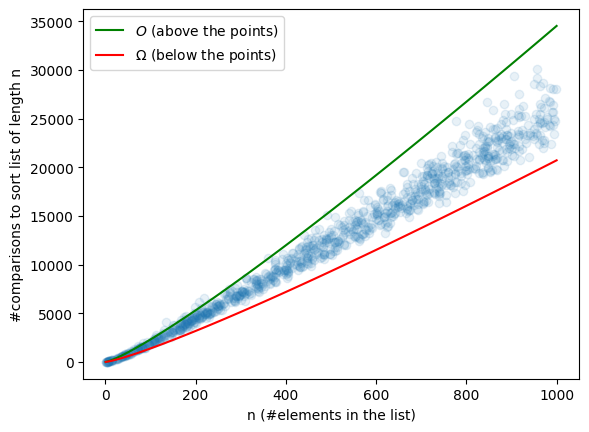

In [45]:
resa = np.array(res)

plt.scatter(*resa.T, alpha=0.1)
ns = np.linspace(1, N, 100)

C_u2, C_u3 = 5, 0.00 # change these...
C_d2, C_d3 = 3, 0.000 # and these!
# see lines 10, 11 what these constants do

plt.plot(ns, C_u2*ns*np.log(ns) + C_u3*ns**2, c='g', label=r'$O$ (above the points)')
plt.plot(ns, C_d2*ns*np.log(ns) + C_d3*ns**2, c='r', label=r'$\Omega$ (below the points)')
plt.legend()
plt.xlabel('n (#elements in the list)')
plt.ylabel('#comparisons to sort list of length n');

# Formalism: Big Oh et al.

In computer science, the $O, \Omega, \Theta$ notations are used to compare computational complexity of algorithms.

> Instead of talking about execution time (in seconds) we will count how many basic operations (additions, multiplications) an algorithm does for input of size $n$.

> Note that people tend to talk about the **running time** of an algorithm, meaning its complexity, and not running time in seconds!


## Short version:
- An algorithm is e.g. $O(n^2)$ if it takes no more than (roughly) $n^2$ operations like additions, multiplications etc. We don't care if it's $3n^2$ or $134425 n^2$, it's all just $O(n^2)$ for us.

- Similarly, say, $Ω(\log{n})$ means we need at least roughly $\log{n}$ operations, even if its $2343242344563221\log{n}$.

- And $Θ(n)$ means we need no less and no more than roughly $n$ operations, so perhaps between $234n$ and $435345n$.



## Long version

By default, we consider the worst-case computational complexity of an algorithm, namely for the worst-possible input. Sometimes, we also consider about the expected case, namely evarage over all inputs.

> So we can say things like "this algorithm does roughly $n^2$ operations" -- but using fancy mathematical notation which makes us sound smart.

We will think about a function $T(n)$, which tells us the number of operations done for input of size $n$.

We say $T(n) = O(g(n))$ if and only if $∃\ c,n_0 \in \mathbb{N}\ such\ that \ T(n)\leq cg(n) \ ∀n > n_0$.


> In plain words: for large enough $n$ our algorithm with complexity $T(n)$ is **not slower** than some other function $g(n)$.

> Example: computing the norm of a vector of length $n$ is $O(n^2)$, but more precisely it is also $O(n)$.

> And yes, $=$ is a terrible choice here, since it doesn't really mean equality! But people use it. More correctly we'd say $T(n) \in O(g(n))$, but almost noone writes it like that...

## There are two others, which are not used as often:

We say $T(n) = Ω(g(n))$ if and only if $∃\ c,n_0 \in \mathbb{N}\ such\ that \ cT(n) \geq g(n) \ ∀n > n_0$.

> In plain words: for large enough $n$ our algorithm with complexity $T(n)$ is **not faster** than $g(n)$.

> Example: computing the norm of a vector of length $n$ is $Ω(1)$, but more precisely $Ω(n)$.

We say $T(n) = Θ(g(n))$ if and only if $T(n) = O(g(n))\ and \ T(n) = Ω(g(n))$.

> In plain words: for large enough $n$ our algorithm with complexity $T(n)$ is exactly **as fast** as g(n).

> Example: computing the norm of a vector of length $n$ is $Θ(n)$.

# Efficiency hierarchy

From fastest to slowest:
$O(1), O(\log{\log{n}}), O(\log{n}), O(\sqrt{n}), O(n), O(n\log{n}), O(n^2), O(n^3), O(2^n), O(n!)$

Caveates:

- $n = O(n^2)$ (but $n^2 \neq O(n)$, so this $=$ is not a **real equality**)

- $n^2 + 344345443n + 1234343 = O(n^2)$

- $123\sqrt{n} + 4354354433343321 = O(n)$


- https://numpy.org/devdocs/reference/generated/numpy.sort.html <- they use the O notation to describe various sorting algorithms used by numpy


## Other parameters

It's often convenient to talk about other parameters, not only the input size.
We will often introduce the dimension of vectors, let's call it $d$.

It's useful in situations like:
> Compute all pairwise distances within $n$ vectors of dimension $d$.

Often we will perform several iteration of some algorithm -- we can make this a parameter too.

# Quick Task 0.5

So what the worst-case complexity of the sorting algorithm above?

> It's a little of a tricky question!

## Task 0.75:

# What's the (worst case) computational complexity of the below algorithms (A-D).

In [46]:
def A(L):
  s = 0
  for x in L:
    s += s
  return s
# O(n)


def B(n):
  s = 0
  for i in range(n):
    for j in range(n):
      s += i*j

  for i in range(n):
    for j in range(n):
      s += i*j+1

    for j in range(n):
      s += i

  for i in range(n):
      s += i

  return s

# O(n^2)

def C(n):
  s = 0
  for i in range(n):
    for j in range(n):
      if 2**j > i:
        break
      s += i*j
  return s

# ---

def C2(n):
  s = 0
  for i in range(n):
    for j in range(n):
      if j > 3:
        break
      s += i*j
  return s

def D(X, Y):
  s = 0
  for a,b in zip(X,Y):
    s += np.linalg.norm(a-b) # has for loop: for i in range(d):
  return 0

# O(nd) -> d = dimension

# Harder task 2

Given an array $X$ of True/False values of length $n$, we'd like to know
how many times True appears between indices $a$ and $b$ (exclusive).

For example if $X$ is [True, False, True, True, True],
count(X, 1, 4) is 2.

What is its worst-case computational complexity wrt $n$? And if we use $a$ and $b$ as parameters?



In [ ]:
X = np.random.rand(1000) < 0.6

# naive solution -- what's the complexity?
def count(X, a, b):
  c = 0
  for i in range(a, b):
    if X[i]:
      c += 1
  return c

print(count(X, 0, 5), X[:5])

Suppose someone wants to call function count many many times. Could we proprocess the data somehow so that each such query is faster?

- How fast can we make each query?
- How slow does the preprocessing have to be for this?

In [ ]:
def preproc(X):
 pass

def query(XP, a, b):
  pass

XP = preproc(X)
a, b = 10, 123
assert query(XP, a, b) == count(X, a, b)

# Optional Task 3:
Binary search can be used to find an element in a sorted array (of,  say, integers).

It can be used to find x s.t. $f(x)$ equals a given $y$ for a monotonous real-valued function. This is actually easier to implement.

Can you implement binary search for sorted arrays? It's an 'easy' problem on leetcode: https://leetcode.com/problems/binary-search/

Actually, I totally challenge you do it on first try -- as in type it up and submit it without running/testing first?

> Ideally, just do a single comparison inside per 'step'.

> Tip: it's not really that easy.

# Extra: Iterative numerical algorithms

The algorithms we'll play with (e.g. kMeans, tSNE) will often be at the intersection of 'standard' algorithms and numerical algorithms. Typically they will be iterative algorithms. This means that the solution is found by getting an increasingly better approximations.

The task below is meant as the first contact with implementing nontrivial algorithms. This should innoculate (some of) you before we start discussing complex algorithms like k-means, tSNE or (later) backpropagation.

# Optional Task 4

Given a function $f : \mathbb{R} \to \mathbb{R}$, find the argument for which it achieves its minimum.

> We're assuming $f$ has a unique minimum. If we allow multiple (local) minima, things get difficult.

> We do NOT assume the function is differentiable. So no gradient descent and relatives for now, please. Also, if you know what that means, we're not assuming the function is convex.

Below is a simple implementation which  returns the minimum up to $epsilon = (to_x - from_x)/budget$.

Try to improve this function. How much better can we lower the budget and get similar results?

In [ ]:
# do something better!
def minimum_of_function(f, from_x, to_x, budget):
  xs = np.linspace(from_x, to_x, budget)
  index_of_minimum = np.argmin(f(xs))
  return xs[index_of_minimum]

In [ ]:
def flat_fun(x):
  log = np.log
  return x*np.log(x) - x**2 + (1-x)*log(1-x) - (1-x)**2

fun, a, b = np.cos, 0, 5
#fun, a, b = flat_fun, 1e-6, 1-1e-6

xs = np.linspace(a, b, 10_000)

plt.plot(xs, fun(xs))

x_min = minimum_of_function(fun, a, b, budget = 10)

plt.axhline(fun(x_min), alpha = 0.3)
plt.axvline(x_min, alpha = 0.3)